# Distribuciones Discretas Notables:
# Modelado y Simulación de Procesos de Bernoulli y Eventos Raros
# Grupo A

# Tarea 1: Modelado Computacional de la Distribución Binomial


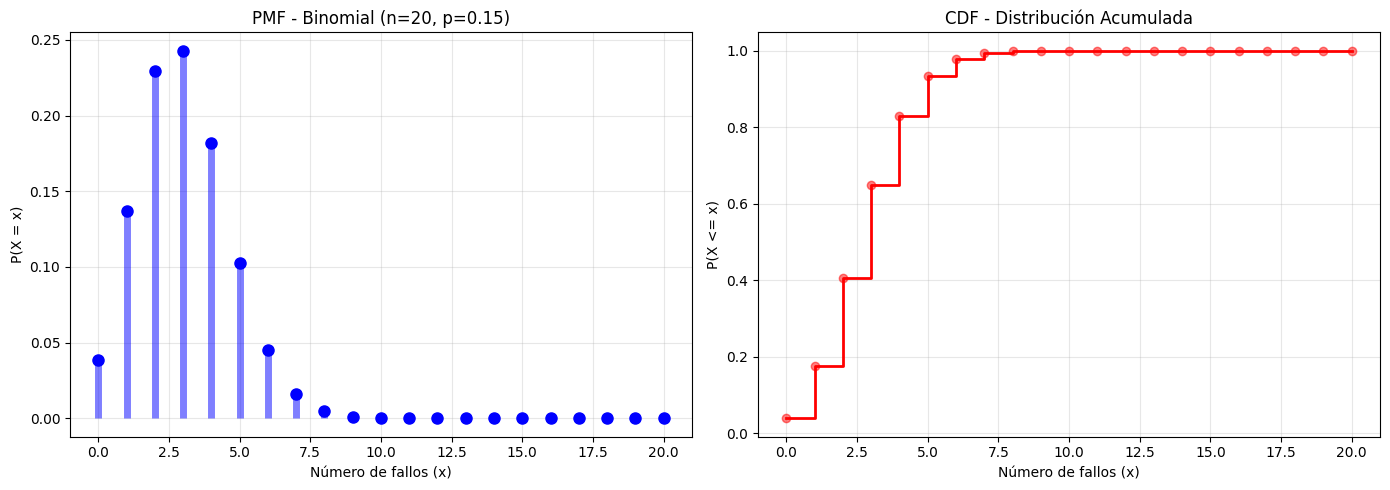

La probabilidad de tener 3 fallos o menos es: 0.6477


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
# Parámetros del modelo Binomial
n_ensayos = 20
p_falla = 0.15
# Dominio de la variable aleatoria (0 a n)
x = np.arange(0, n_ensayos + 1)
# Cálculo de PMF (Función de Masa) y CDF (Función Acumulada)
pmf_binomial = binom.pmf(x, n_ensayos, p_falla)
cdf_binomial = binom.cdf(x, n_ensayos, p_falla)
# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico PMF
ax[0].vlines(x, 0, pmf_binomial, colors='b', lw=5, alpha=0.5)
ax[0].plot(x, pmf_binomial, 'bo', ms=8)
ax[0].set_title(f'PMF - Binomial (n={n_ensayos}, p={p_falla})')
ax[0].set_xlabel('Número de fallos (x)')
ax[0].set_ylabel('P(X = x)')
ax[0].grid(True, alpha=0.3)
# Gráfico CDF
ax[1].step(x, cdf_binomial, where='post', color='r', lw=2)
ax[1].plot(x, cdf_binomial, 'ro', alpha=0.5)
ax[1].set_title('CDF - Distribución Acumulada')
ax[1].set_xlabel('Número de fallos (x)')
ax[1].set_ylabel('P(X <= x)')
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Cálculo de probabilidad específica: P(X <= 3)
prob_max_3 = binom.cdf(3, n_ensayos, p_falla)
print(f"La probabilidad de tener 3 fallos o menos es: {prob_max_3:.4f}")

# Tarea 2: Modelado de la Distribución de Poisson (Eventos Raros)

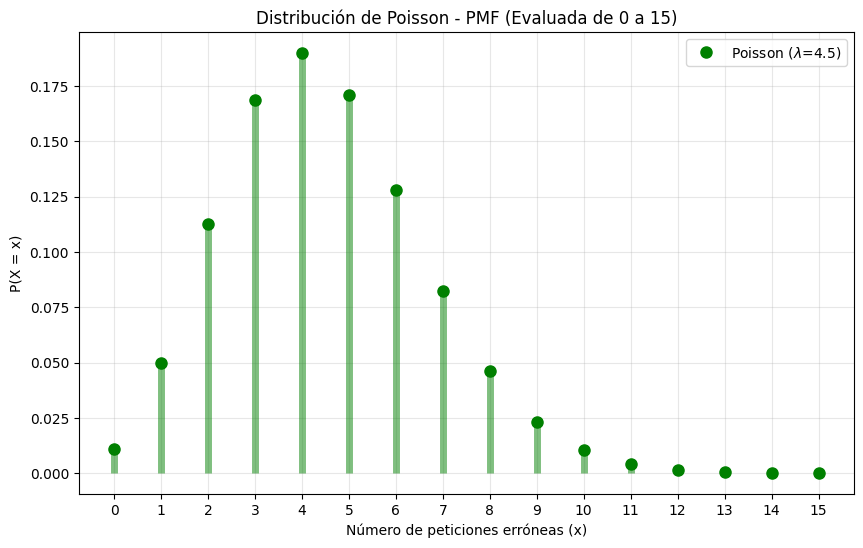

La probabilidad exacta de recibir exactamente 6 peticiones es: 0.1281


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parámetros del modelo de Poisson
lam = 4.5  # Tasa media de peticiones erróneas λ (lambda)

# Dominio de la variable aleatoria (de 0 a 15 según la tarea)
x = np.arange(0, 16)

# Cálculo de la PMF (Función de Masa de Probabilidad)
pmf_poisson = poisson.pmf(x, lam)

# Visualización de la PMF
plt.figure(figsize=(10, 6))
plt.vlines(x, 0, pmf_poisson, colors='g', lw=5, alpha=0.5)
# Se agrega la 'r' antes de las comillas en el label para evitar el error de \l
plt.plot(x, pmf_poisson, 'go', ms=8, label=fr'Poisson ($\lambda$={lam})')

# Personalización del gráfico
plt.title(f'Distribución de Poisson - PMF (Evaluada de 0 a 15)')
plt.xlabel('Número de peticiones erróneas (x)')
plt.ylabel('P(X = x)')
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 5. Cálculo de la probabilidad exacta: P(X = 6)
prob_exacta_6 = poisson.pmf(6, lam)

print(f"La probabilidad exacta de recibir exactamente 6 peticiones es: {prob_exacta_6:.4f}")

# Tarea 3: Hito del Proyecto - Identificación de Variables de Conteo (ABP)


Media muestral λ (Total mensual - accidentes.csv): 32.54
Media muestral λ (Por causa individual - acccausas.csv): 8.32


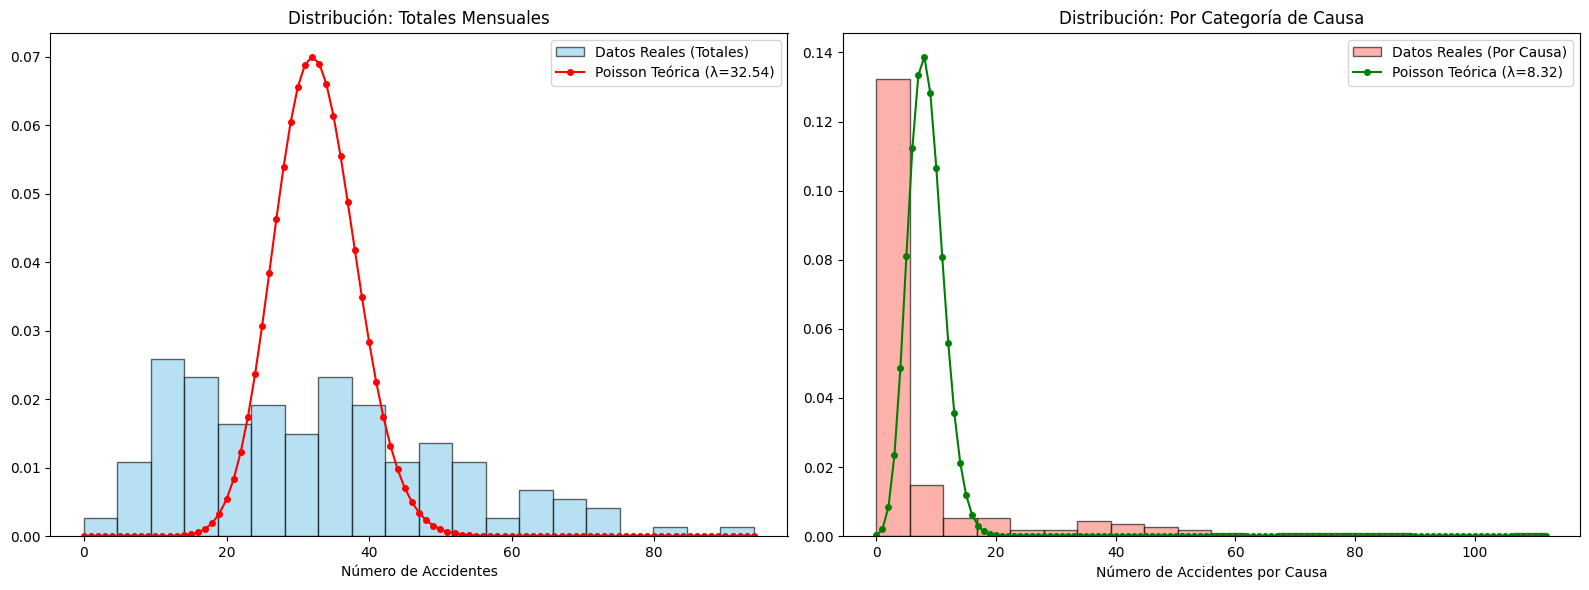

Los gráficos muestran que la realidad no sigue la teoría, dado que los datos dentro de los dos datasets, si bien son de conteo, estos siguen una alta variabilidad
y fluctuación entre periodos de tiempo, dado por fenómenos que elevan o bajan drásticamente las mediciones, evitando que sean constantes, algo importante para trabajar con Poisson.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Carga de ambos datasets
df_accidentes = pd.read_csv("accidentes.csv")
df_causas = pd.read_csv("acccausas.csv", on_bad_lines="skip")

# Identificación de las variables discretas
data_acc = df_accidentes['numero']
data_cau = df_causas['numero'] # Nueva variable añadida de acccausas.csv [1]

# Cálculo de parámetros lambda (λ) para ambos modelos
lambda_acc = data_acc.mean()
lambda_cau = data_cau.mean()

print(f"Media muestral λ (Total mensual - accidentes.csv): {lambda_acc:.2f}")
print(f"Media muestral λ (Por causa individual - acccausas.csv): {lambda_cau:.2f}")

# Generación de gráficos comparativos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico A: Dataset Accidentes---
ax1.hist(data_acc, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Datos Reales (Totales)')
x_acc = np.arange(int(data_acc.min()), int(data_acc.max()) + 1)
ax1.plot(x_acc, poisson.pmf(x_acc, lambda_acc), 'ro-', ms=4, label=f'Poisson Teórica (λ={lambda_acc:.2f})')
ax1.set_title('Distribución: Totales Mensuales')
ax1.set_xlabel('Número de Accidentes')
ax1.legend()

# --- Gráfico B: Dataset Causas---
ax2.hist(data_cau, bins=20, density=True, alpha=0.6, color='salmon', edgecolor='black', label='Datos Reales (Por Causa)')
x_cau = np.arange(int(data_cau.min()), int(data_cau.max()) + 1)
ax2.plot(x_cau, poisson.pmf(x_cau, lambda_cau), 'go-', ms=4, label=f'Poisson Teórica (λ={lambda_cau:.2f})')
ax2.set_title('Distribución: Por Categoría de Causa')
ax2.set_xlabel('Número de Accidentes por Causa')
ax2.legend()

plt.tight_layout()
plt.show()


print("Los gráficos muestran que la realidad no sigue la teoría, dado que los datos dentro de los dos datasets, si bien son de conteo, estos siguen una alta variabilidad")
print("y fluctuación entre periodos de tiempo, dado por fenómenos que elevan o bajan drásticamente las mediciones, evitando que sean constantes, algo importante para trabajar con Poisson.")



# Tarea 4: ABI - Aproximación Binomial a Poisson

## **Condiciones en las que una distribución binomial se aproxima a una poisson**


#### Las condiciones tienen que ser muy “raras” para que esto se cumpla, teniendo en cuenta que n (el número de iteraciones) tiene que tender al infinito o poniéndolo en un valor específico sería n >= 100 iteraciones, la probabilidad debe ser muy pequeña o tender a 0 si usamos un dato matemático sería P <= 0.05 tambíen puede ser un valor más alto o máximo de P <= 0.1.
La variable de P tiene que aumentar en proporción del incremento de n, si la variable P no cambia mientras n incrementa entonces se aproxima más a una distribución normal y no a la distribución Poisson.


## **Relación de $\lambda = np$  cuando $n \to \infty$ y $p \to 0$:**
#### Teniendo en cuenta que las variables tienden a valores muy lejanos uno de otro, cuando tenemos este caso no podemos contar un número específico de iteraciones o la probabilidad de éxito por cada caso, al tener las variables tomando valores tan extremos a lo que se recurre es a usar una constante en este caso **$\lambda$**, la formula quedaría $\lambda = n*p$ donde esto permite un equilibrio y hace que los valores tan caóticos se vuelvan predecibles para un análisis, puesto que mantiene el "promedio" y el flujo en movimiento de los datos de **n y p** haciendo que p dismuniya al mismo ritmo que n aumenta.


### Modelo Binomial Y Modelo Poisson

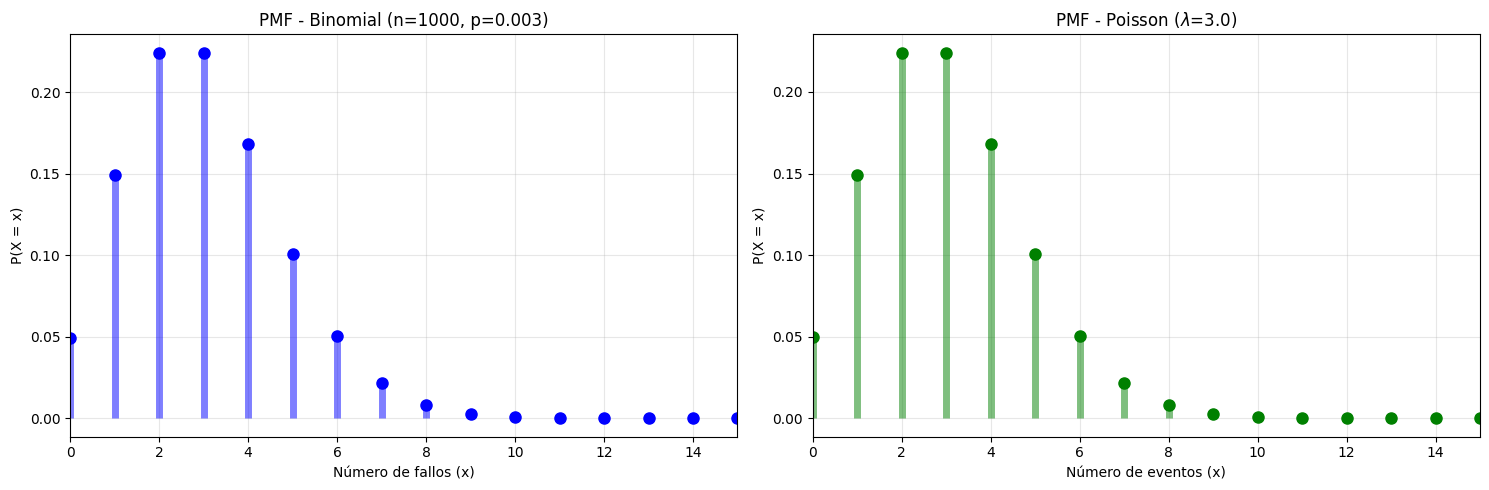

Probabilidad Binomial en x=3: 0.224379
Probabilidad Poisson  en x=3: 0.224042
Diferencia: 0.00033676


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

# --- PARÁMETROS ---
n_ensayos = 1000
p_falla = 0.003
lam = n_ensayos * p_falla  # Esto da 3

# Dominio de la variable
x = np.arange(0, 16)

# --- CÁLCULOS ---
pmf_binomial = binom.pmf(x, n_ensayos, p_falla)
pmf_poisson = poisson.pmf(x, lam)

# --- VISUALIZACIÓN ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico Binomial
ax[0].vlines(x, 0, pmf_binomial, colors='b', lw=5, alpha=0.5)
ax[0].plot(x, pmf_binomial, 'bo', ms=8)
# Agregamos la 'r' antes de las comillas para evitar el SyntaxWarning
ax[0].set_title(fr'PMF - Binomial (n={n_ensayos}, p={p_falla})')
ax[0].set_xlabel('Número de fallos (x)')
ax[0].set_ylabel('P(X = x)')
ax[0].set_xlim(0, 15)
ax[0].grid(True, alpha=0.3)

# Gráfico Poisson
ax[1].vlines(x, 0, pmf_poisson, colors='g', lw=5, alpha=0.5)
ax[1].plot(x, pmf_poisson, 'go', ms=8)
# Agregamos la 'r' aquí también para que \lambda funcione bien
ax[1].set_title(fr'PMF - Poisson ($\lambda$={lam})')
ax[1].set_xlabel('Número de eventos (x)')
ax[1].set_ylabel('P(X = x)')
ax[1].set_xlim(0, 15)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- COMPARACIÓN DE VALORES ---
prob_bin = binom.pmf(3, n_ensayos, p_falla)
prob_poi = poisson.pmf(3, lam)

print(f"Probabilidad Binomial en x=3: {prob_bin:.6f}")
print(f"Probabilidad Poisson  en x=3: {prob_poi:.6f}")
print(f"Diferencia: {abs(prob_bin - prob_poi):.8f}")

# Pregunta 5

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Se extraen las variables discretas
data_acc = df_accidentes['numero']
data_cau = df_causas['numero']

# Cálculo de Media (E[X]) y Varianza (V[X])
# Para Poisson, teóricamente Media == Varianza
stats = {
    "Dataset Accidentes": {
        "Media (λ)": data_acc.mean(),
        "Varianza": data_acc.var()
    },
    "Dataset Causas": {
        "Media (λ)": data_cau.mean(),
        "Varianza": data_cau.var()
    }
}

print("--- ANÁLISIS DE PROPIEDADES DE POISSON ---")
for nombre, valores in stats.items():
    print(f"\n{nombre}:")
    print(f"  - Media Muestral: {valores['Media (λ)']:.2f}")
    print(f"  - Varianza Muestral: {valores['Varianza']:.2f}")


--- ANÁLISIS DE PROPIEDADES DE POISSON ---

Dataset Accidentes:
  - Media Muestral: 32.54
  - Varianza Muestral: 333.28

Dataset Causas:
  - Media Muestral: 8.32
  - Varianza Muestral: 297.58
